In [19]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim
from tqdm import tqdm
import pandas as pd
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import wandb

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#login to wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


False

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

In [21]:
train_prior_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform)

#split this into training and validation data
#train_dataset = train_prior_dataset.sample(frac=0.8, random_seed=42) #use 80% of supposed train data from MINST as actual training data

#val_dataset = train_prior_dataset.drop(train_dataset.index) #use remaining 20% to validate training data

train_size = int(0.8*len(train_prior_dataset))
val_size = len(train_prior_dataset) - train_size

train_dataset, val_dataset = random_split(train_prior_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

In [22]:
test_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
)

In [23]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [24]:
images, labels = next(iter(train_loader))
print(f"Images tensor shape: {images.shape}")
print(f"Labels tensor shape: {labels.shape}")
print(f"Labels in this batch: {labels}")

Images tensor shape: torch.Size([64, 1, 28, 28])
Labels tensor shape: torch.Size([64])
Labels in this batch: tensor([8, 5, 5, 3, 1, 7, 5, 2, 4, 2, 9, 9, 3, 3, 0, 5, 4, 0, 2, 8, 5, 2, 9, 1,
        4, 1, 2, 8, 5, 1, 6, 5, 6, 2, 0, 5, 7, 9, 0, 8, 3, 6, 7, 0, 2, 0, 1, 3,
        7, 5, 5, 5, 1, 6, 0, 0, 4, 3, 9, 5, 3, 9, 8, 6])


# **MLP MODEL**

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, 10)
        self.relu = nn.ReLU() #first activation
        self.flatten = nn.Flatten() ## this will allow us to flatten the images
        self.dropout = nn.Dropout(0.3) #helps with overfitting

    def forward(self, x):
        x = self.flatten(x) ## this will allow us to flatten the images into vectors
        x = self.linear(x)
        x = self.relu(x) #2nd activation
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.relu(x) #third activation
        x = self.dropout(x)
        x = self.linear3(x)
        return x  # returns logits

In [ ]:
model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)  # mini-batch SGD


print("\nModel architecture:")
print(model)


Model architecture:
SimpleClassifier(
  (linear): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
#wandb innitialized for MLP Model
wandb.init(
    project = "Assignment 5 deep learning",
    name = "MLP Run",
    config = {
        "epochs": 50,
        "batch_size": 64,
        "learning_rate": 0.001,
        "architecture": "MLP"
    }
)

In [ ]:
epochs = 50
losses = []
fin_loss_train = 0

val_loss = []
fin_loss_val = 0
val_accuracy = 0
samp_tot_val = 0
val_accuracy_epoch = [] #since we want it to reset after every epoch, we store as an array
#len_val_accurary = 0
for epoch in range(epochs): #for every single epoch
    epoch_loss = 0.0

    #train mode
    model.train()
    # dataloader automatically handles shuffling each epoch
    for X_batch, y_batch in tqdm(train_loader, desc='Training'):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Step 1: Forward pass - get logits
        logits = model(X_batch)

        # Step 2: Compute loss (CrossEntropyLoss expects logits)
        loss = criterion(logits, y_batch)
        epoch_loss += loss.item()

        # Step 3: Zero gradients
        optimizer.zero_grad()

        # Step 4: Backward pass - compute gradients automatically
        loss.backward()

        # Step 5: Update weights
        optimizer.step()

    # Record average loss
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    #switch to evaluation mode
    model.eval()
    epoch_l_val = 0.0
    for X_batch_val, y_batch_val in tqdm(val_loader, desc='Validation'):
        X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)

        with torch.no_grad():
          logit_v = model(X_batch_val)

          #use cross entropy to compute loss of validation data
          loss_val = criterion(logit_v, y_batch_val)
          #val_loss.append(loss_val)

          epoch_l_val += loss_val.item()

          predicted_mod_val = torch.argmax(logit_v, dim=1) #gets the predicted values

          #y_batch_val_comp = y_batch_val.argmax(dim=1)
          #compare predicted with actual y_batch values
        for i in range(len(predicted_mod_val)):
          if predicted_mod_val[i] == y_batch_val[i]:
            val_accuracy += 1
          else:
            val_accuracy += 0

        samp_tot_val += len(y_batch_val)

    #calculate the avg of validation accurary for that epoch.
    interm_val_accuracy_ep = val_accuracy / samp_tot_val
    #interm_val_acc_epoch_percent = interm_val_accuracy_ep * 100

    #store avg validation accuracy to list for epoch
    val_accuracy_epoch.append(interm_val_accuracy_ep)

    #reset val_accuracy to zero per epoch
    val_accuracy = 0
    samp_tot_val = 0

    #store loss of validation data
    avg_val_loss = epoch_l_val / len(val_loader)
    val_loss.append(avg_val_loss)

    #log the metrics to wandb
    wandb.log({
    "train_loss": avg_loss,
    "val_loss": avg_val_loss,
    "val_accuracy": interm_val_accuracy_ep
    })

#get avg overall loss for all epochs for train and validation
fin_loss_train = sum(losses) / len(losses)
fin_loss_val = sum(val_loss) / len(val_loss)

#compute how accurate model is
accuracy = (sum(val_accuracy_epoch) / len(val_accuracy_epoch))

print(f"Epoch Train {epoch+1:3d}/{epochs} | Loss Train: {fin_loss_train:.4f}")
print(f"Epoch Val {epoch+1:3d}/{epochs} | Loss Val: {fin_loss_val:.4f}")
print(f"Accuracy of Validation: ", accuracy)

Validation: 100%|██████████| 188/188 [00:03<00:00, 62.34it/s]


Epoch Train  50/50 | Loss Train: 0.6857
Epoch Val  50/50 | Loss Val: 0.5876
Accuracy of Validation:  0.7960033333333334


### **Accurary**
Accuracy is a performance metric used to evaluate how well a model makes predictions. It measures the proportion of correct predictions made by the model compared to the total number of predictions. It is calculated by dividing the number of correct predictions by the total number of predictions.

### **Confusion Matrix**
A confusion matrix is a table used to evaluate the performance of a classification model by comparing predicted values to actual values. Each row represents the actual class, while each column represents the predicted class. The diagonal elements show correct predictions, while the off-diagonal elements represent misclassifications.

## **Testing MLP Model Performance**

In [ ]:
#testing set
y_predict = []
y_actual = []
model.eval()
for X_batch_test, y_batch_test in tqdm(test_loader, desc='Testing'):
  X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)
  with torch.no_grad():
    #get predictions probability/score
    y_predict_prob = model(X_batch_test)

    #get the highest probability/score
    y_pred_test = torch.argmax(y_predict_prob, dim=1)
    y_predict.append(y_pred_test)

    y_actual.append(y_batch_test)
print(len(y_actual))
print(len(y_predict))

#combine/concatonates the different batches vals in lists into 1
y_predict_cat = torch.cat(y_predict)
y_actual_cat = torch.cat(y_actual)

#move them to CPU
#y_predict_cat = y_predict_cat.cpu().numpy()
#y_actual_cat = y_actual_cat.cpu().numpy()

#compute the accuracy using the scikit learn
accuracy_test = accuracy_score(y_actual_cat, y_predict_cat)

#log accurary matrix to wandb
wandb.log({
    "test_accuracy": accuracy_test
})

#compute the confusion matrix using the scikit learn
test_conf_matrix = confusion_matrix(y_actual_cat, y_predict_cat)

#print accuracy and matrix
print(f"Accuracy of Test: ", accuracy_test)
print(f"Confusion Matrix of Test dat: ", test_conf_matrix)







Testing: 100%|██████████| 157/157 [00:02<00:00, 62.23it/s]


157
157
Accuracy of Test:  0.8359
Confusion Matrix of Test dat:  [[826   1   8  48   5   6  95   0  11   0]
 [  2 951   6  31   6   0   3   0   1   0]
 [ 18   0 730  12 147   0  83   0  10   0]
 [ 33  11   7 861  40   1  42   0   5   0]
 [  0   0  93  32 781   0  88   0   6   0]
 [  0   0   0   1   0 895   0  62   3  39]
 [194   2 125  34 103   1 510   0  31   0]
 [  0   0   0   0   0  39   0 911   0  50]
 [  1   1   9   9   3   5  15   4 952   1]
 [  0   0   0   0   0  14   0  43   1 942]]


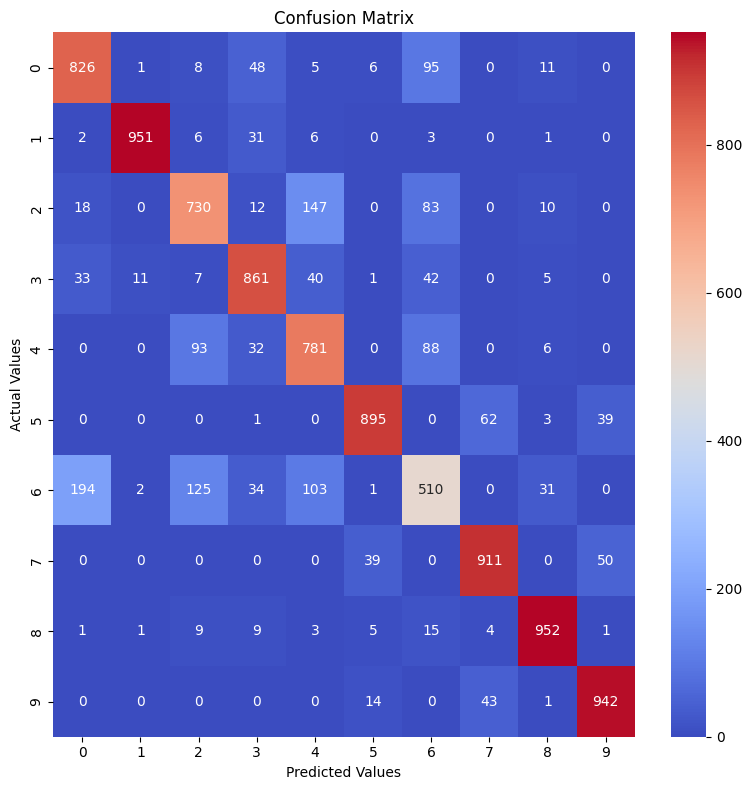

In [ ]:
#graph the matrix for visual cue

plt.figure(figsize=(8,8))
sns.heatmap(data=test_conf_matrix, annot=True, cmap='coolwarm', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.tight_layout()
plt.show()

### **MLP Confusion Matrix Discussion**
The confusion matrix for this model (MLP) show that most predictions lie along the diagonal, indicating somewhat correct classifications.
However, there are lots of noticeable misclassifications between certain classes. This suggests that the model struggles to distinguish between visually similar categories. One can hypothesize that these errors occur because the MLP model does not take into account the spatial structure of the images, making it harder to differentiate between similar patterns.

In [ ]:
#Discusion of results for this model

#print accuracy value of dalidation data
print(f"Accuracy of Validation data: ", accuracy*100)

#print accuracy value of test data
print(f"Accuracy of Test: ", accuracy_test*100)


Accuracy of Validation data:  79.60033333333334
Accuracy of Test:  83.59


### **Accuracy comparison across Validation data and Test data for MLP Model**
The Testing data had a lower performance (70.52%) compared to that of the validation data (71.32%) and both didn't perform really well. Usually an accuracy of 90% or more is considered strong model performance and this model outputted ~70%. Something to note is that since the MLP model flattens the input images into vectors, it does not preserve spatial relationships between pixels. This in turn can limit its ability to capture important patterns such as edges and shapes in the images.

# **CNN MODEL**

In [25]:
#CNN model class implementation
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        #convolution layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        #halv imgs size
        self.pool = nn.MaxPool2d(2, 2)

        #first activation plus flattening of imgs
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        #fully connected lyrs
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        #conv1 layer
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        #conv2 layer
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        #flatten
        x = self.flatten(x)

        #fully conect layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [26]:
#create the CNN model
model_cnn = CNNClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_cnn.parameters(), lr=0.001)  # mini-batch SGD


print("\nModel architecture:")
print(model_cnn)


Model architecture:
CNNClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [27]:
#wandb innitialized for CNN Model
wandb.init(
    project = "Assignment 5 deep learning",
    name = "CNN Run",
    config = {
        "epochs": 50,
        "batch_size": 64,
        "learning_rate": 0.001,
        "architecture": "CNN"
    }
)

train_loss,█▅▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▄▅▅▅▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
val_loss,█▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.33657
val_accuracy,0.878
val_loss,0.35385


## **Training and validation of CNN Model using same codes as MLP model**

In [28]:
epochs = 50
losses = []
fin_loss_train = 0

val_loss = []
fin_loss_val = 0
val_accuracy = 0
samp_tot_val = 0
val_accuracy_epoch = [] #since we want it to reset after every epoch, we store as an array
#len_val_accurary = 0
for epoch in range(epochs): #for every single epoch
    epoch_loss = 0.0

    #in training mode
    model_cnn.train()
    # dataloader automatically handles shuffling each epoch
    for X_batch, y_batch in tqdm(train_loader, desc='Training'):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Step 1: Forward pass - get logits
        logits = model_cnn(X_batch)

        # Step 2: Compute loss (CrossEntropyLoss expects logits)
        loss = criterion(logits, y_batch)
        epoch_loss += loss.item()

        # Step 3: Zero gradients
        optimizer.zero_grad()

        # Step 4: Backward pass - compute gradients automatically
        loss.backward()

        # Step 5: Update weights
        optimizer.step()

    # Record average loss
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)


    #switch to evaluation mode
    model_cnn.eval()
    epoch_l_val = 0.0
    for X_batch_val, y_batch_val in tqdm(val_loader, desc='Validation'):
        X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)

        with torch.no_grad():
          logit_v = model_cnn(X_batch_val)

          #use cross entropy to compute loss of validation data
          loss_val = criterion(logit_v, y_batch_val)
          #val_loss.append(loss_val)

          epoch_l_val += loss_val.item()

          predicted_mod_val = torch.argmax(logit_v, dim=1) #gets the predicted values

          #y_batch_val_comp = y_batch_val.argmax(dim=1)
          #compare predicted with actual y_batch values
        for i in range(len(predicted_mod_val)):
          if predicted_mod_val[i] == y_batch_val[i]:
            val_accuracy += 1
          else:
            val_accuracy += 0

        samp_tot_val += len(y_batch_val)

    #calculate the avg of validation accurary for that epoch.
    interm_val_accuracy_ep = val_accuracy / samp_tot_val
    #interm_val_acc_epoch_percent = interm_val_accuracy_ep * 100

    #store avg validation accuracy to list for epoch
    val_accuracy_epoch.append(interm_val_accuracy_ep)

    #reset val_accuracy to zero per epoch
    val_accuracy = 0
    samp_tot_val = 0

    #store loss of validation data
    avg_val_loss = epoch_l_val / len(val_loader)
    val_loss.append(avg_val_loss)

    #log the metrics to wandb
    wandb.log({
    "train_loss": avg_loss,
    "val_loss": avg_val_loss,
    "val_accuracy": interm_val_accuracy_ep
    })

#get avg overall loss for all epochs for train and validation
fin_loss_train = sum(losses) / len(losses)
fin_loss_val = sum(val_loss) / len(val_loss)

#compute how accurate model is
accuracy_cnn = (sum(val_accuracy_epoch) / len(val_accuracy_epoch))

print(f"Epoch Train {epoch+1:3d}/{epochs} | Loss Train: {fin_loss_train:.4f}")
print(f"Epoch Val {epoch+1:3d}/{epochs} | Loss Val: {fin_loss_val:.4f}")
print(f"Accuracy of Validation: ", accuracy_cnn)

Validation: 100%|██████████| 188/188 [00:07<00:00, 25.35it/s]

Epoch Train  50/50 | Loss Train: 0.4912
Epoch Val  50/50 | Loss Val: 0.4859
Accuracy of Validation:  0.831105


## **Testing CNN Model Performance**

In [29]:
#testing set
y_predict = []
y_actual = []
model_cnn.eval()
for X_batch_test, y_batch_test in tqdm(test_loader, desc='Testing'):
  X_batch_test, y_batch_test = X_batch_test.to(device), y_batch_test.to(device)
  with torch.no_grad():
    #get predictions probability/score
    y_predict_prob = model_cnn(X_batch_test)

    #get the highest probability/score
    y_pred_test = torch.argmax(y_predict_prob, dim=1)
    y_predict.append(y_pred_test)

    y_actual.append(y_batch_test)
print(len(y_actual))
print(len(y_predict))

#combine/concatonates the different batches vals in lists into 1
y_predict_cat = torch.cat(y_predict)
y_actual_cat = torch.cat(y_actual)

#compute the accuracy using scikit learn
accuracy_test_cnn = accuracy_score(y_actual_cat, y_predict_cat)

#log accurary matrix to wandb
wandb.log({
    "test_accuracy_cnn": accuracy_test_cnn
})
#compute the confusion matrix using scikit learn
test_conf_matrix_cnn = confusion_matrix(y_actual_cat, y_predict_cat)

#print accuracy and matrix
print(f"Accuracy of Test: ", accuracy_test_cnn)
print(f"Confusion Matrix of Test dat: ", test_conf_matrix_cnn)

Testing: 100%|██████████| 157/157 [00:06<00:00, 25.96it/s]

157
157
Accuracy of Test:  0.8562
Confusion Matrix of Test dat:  [[891   1  38  29   4   2  25   0  10   0]
 [  3 968   3  20   2   0   2   0   2   0]
 [ 19   1 913  12  40   0  10   1   4   0]
 [ 36   8  28 878  27   0  19   0   4   0]
 [  1   1 245  36 679   0  34   0   4   0]
 [  0   0   0   2   0 951   0  32   1  14]
 [217   1 217  28  80   0 437   0  20   0]
 [  0   0   0   0   0  31   0 929   0  40]
 [  5   1  16   7   3   1   1   5 960   1]
 [  0   0   0   0   0   6   0  37   1 956]]


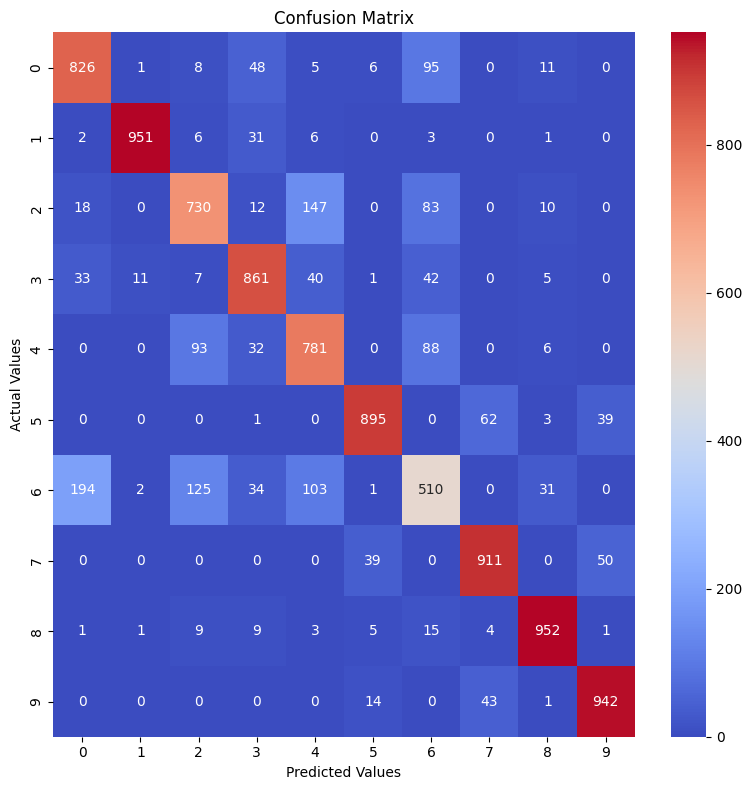

In [30]:
#graph the matrix for visual cue

plt.figure(figsize=(8,8))
sns.heatmap(data=test_conf_matrix, annot=True, cmap='coolwarm', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.tight_layout()
plt.show()

### **CNN Confusion Matrix Discussion**
The confusion matrix for this model (CNN), show a much stronger concentration indicating improved classification performance.
There are fewer misclassifications overall which demonstrating that CNN is better at distinguishing between similar classes but still not the best.

In [31]:
#Discusion of results for this model

#print accuracy value of dalidation data
print(f"Accuracy of Validation data: ", accuracy_cnn*100)

#print accuracy value of test data
print(f"Accuracy of Test: ", accuracy_test_cnn*100)

Accuracy of Validation data:  83.1105
Accuracy of Test:  85.61999999999999


### **Accuracy comparison across Validation data and Test data for CNN Model**
The Testing data had a slightly better performance (84.01%) compared to that of the validation data (82.01%) although both performed really well. Something to note is that CNN performs better as it is specifically designed for image data. By using convolutional layers, the model is able to detect spatial features such as edges, textures, and shapes.

# **Comparison of CNN and MLP Model Performance**


In [32]:
#Discusion of results for CNN vs MLP

#print accuracy value of MLP test data
print(f"Accuracy of Validation data: ", accuracy_test*100)

#print accuracy value of CNN test data
print(f"Accuracy of Test: ", accuracy_test_cnn*100)

Accuracy of Validation data:  83.59
Accuracy of Test:  85.61999999999999


When comparing the two models, the CNN outperformed the MLP in terms of both validation and test accuracy.
Specifically, the CNN achieved a test accuracy of 84.01%, whereas the MLP achieved 70.52%.
We can attribute this difference in performance to the ability of CNNs to preserve spatial information through convolutional operations, whereas MLPs treat the input as a flat vector and lose this information.
Therefore, the CNN is better suited for image classification tasks such as FashionMNIST.

# **Other Discusion Questions**

### **Model Architecture Design and Which we tried**
The MLP architecture consists of fully connected layers with ReLU activation functions. The input images were flattened into vectors before being passed through the network. For this model specifically, different variations (numbers) of hidden layers and neurons was explored to balance model complexity and performance.

As CNNs are known to outperform fully connected networks for image classification, its architecture is designed with two convolutional layers followed by ReLU activations and max-pooling layers. These layers were used to extract spatial features and reduce dimensionality. The output was then flattened and passed through fully connected layers for classification. For this model specifically, different variations (numbers) of convolutional filters and layer configurations was explored to balance model performance and efficiency.


## **W&B Use and Discussion**
Weights & Biases was used to track and visualize model performance during training. The training loss, validation loss, and validation accuracy metrics was logged at each epoch using the Wandb platform.
This platform provided real-time insights into how the model was learning over time.